# Results: TFIM vs Naive Decomposition

Reads result files from `../Results/` and plots scaling comparisons.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

results_dir = os.path.dirname(os.path.abspath("__file__"))

tfim  = pd.read_csv(os.path.join(results_dir, "TFIM_decomposition_times.txt"), sep=r",\s*", engine="python")
naive_times  = pd.read_csv(os.path.join(results_dir, "Naive_decomposition_times.txt"), sep=r",\s*", engine="python")
naive_counts = pd.read_csv(os.path.join(results_dir, "Naive_decomposition_errors_and_counts.txt"), sep=r",\s*", engine="python")

# TFIM gate count is exactly n(2n-1) Pauli rotations by construction
tfim["gate_count"] = tfim["n_qubits"] * (2 * tfim["n_qubits"] - 1)

print("TFIM rows:",    len(tfim))
print("Naive rows:",   len(naive_times))
print("Naive counts:", len(naive_counts))


TFIM rows: 13
Naive rows: 12
Naive counts: 12


## Decomposition time vs n

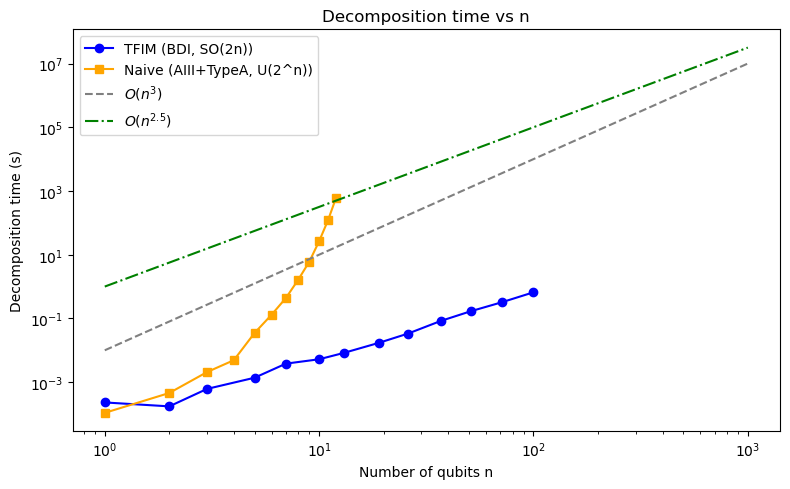

In [89]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tfim["n_qubits"], tfim["decomposition_time"],
        color="blue", marker="o", label="TFIM (BDI, SO(2n))")
ax.plot(naive_times["n_qubits"], naive_times["decomposition_time"],
        color="orange", marker="s", label="Naive (AIII+TypeA, U(2^n))")

# Plot scaling lines for reference
n_ref = np.linspace(1, 1000, 100)
ax.plot(n_ref, 0.01 * n_ref**3, color="gray", linestyle="--", label=r"$O(n^3)$")
ax.plot(n_ref, n_ref**2.5, color="green", linestyle="-.", label=r"$O(n^{2.5})$")

ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Decomposition time (s)")
ax.set_title("Decomposition time vs n")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
#ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "decomposition_time_comparison.png"), dpi=150)
plt.show()


## Gate count vs n

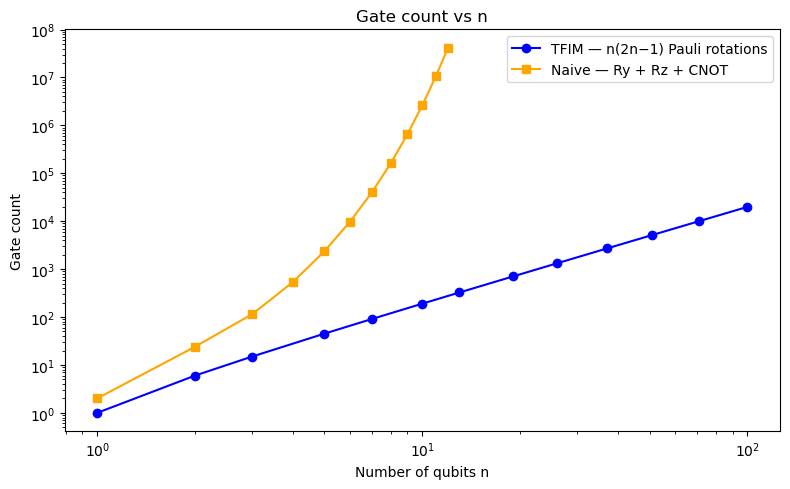

In [90]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(tfim["n_qubits"], tfim["gate_count"],
        color="blue", marker="o", label="TFIM — n(2n−1) Pauli rotations")
ax.plot(naive_counts["n_qubits"], naive_counts["total_gates"],
        color="orange", marker="s", label="Naive — Ry + Rz + CNOT")

ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Gate count")
ax.set_title("Gate count vs n")
ax.set_yscale("log")
ax.set_xscale("log")
ax.legend()
#ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "gate_count_comparison.png"), dpi=150)
plt.show()


## Naive gate count breakdown (Ry, Rz, CNOT)

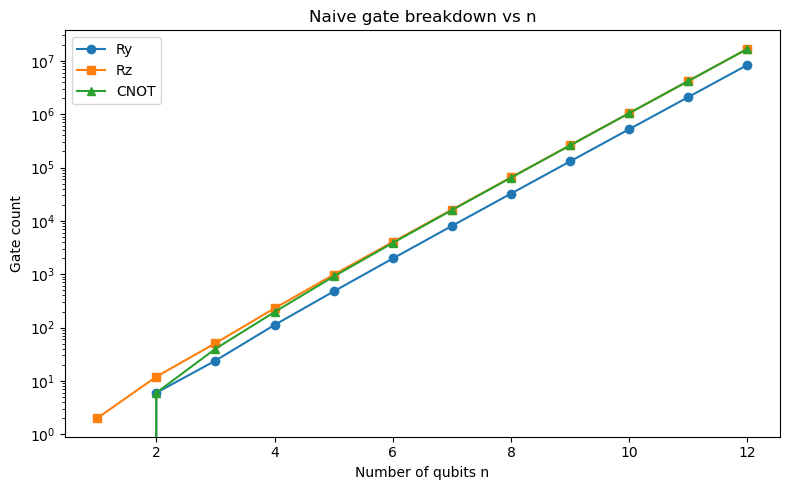

In [91]:
fig, ax = plt.subplots(figsize=(8, 5))

ns = naive_counts["n_qubits"]
ax.plot(ns, naive_counts["Ry"],   marker="o", label="Ry")
ax.plot(ns, naive_counts["Rz"],   marker="s", label="Rz")
ax.plot(ns, naive_counts["CNOT"], marker="^", label="CNOT")

ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Gate count")
ax.set_title("Naive gate breakdown vs n")
ax.set_yscale("log")
ax.legend()
#ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## Reconstruction error vs n (Naive)

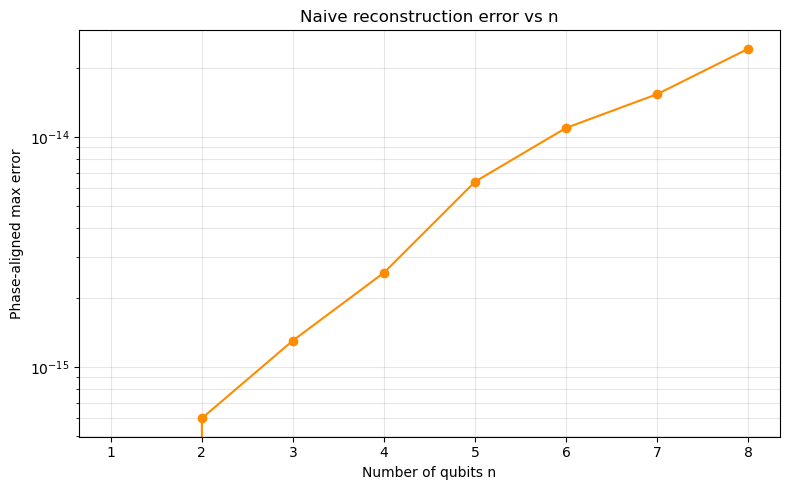

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(naive_counts["n_qubits"], naive_counts["error"],
        color="darkorange", marker="o")

ax.set_xlabel("Number of qubits n")
ax.set_ylabel("Phase-aligned max error")
ax.set_title("Naive reconstruction error vs n")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()


## Scaling exponent fits

In [93]:
from numpy.polynomial import polynomial as P

def fit_power(ns, vals):
    log_n = np.log(ns.astype(float))
    log_v = np.log(vals.astype(float))
    b, a = np.polyfit(log_n, log_v, 1)
    return b

exp_tfim_time  = fit_power(tfim["n_qubits"], tfim["decomposition_time"])
exp_tfim_gates = fit_power(tfim["n_qubits"], tfim["gate_count"])
exp_naive_time = fit_power(naive_times["n_qubits"], naive_times["decomposition_time"])
exp_naive_gates = fit_power(naive_counts["n_qubits"], naive_counts["total_gates"])

print(f"TFIM  decomposition time  ~ n^{exp_tfim_time:.2f}")
print(f"TFIM  gate count          ~ n^{exp_tfim_gates:.2f}  (expected: 2.0)")
print(f"Naive decomposition time  ~ n^{exp_naive_time:.2f}")
print(f"Naive gate count          ~ n^{exp_naive_gates:.2f}  (expected: 4.0 for general U(2^n))")


TFIM  decomposition time  ~ n^1.88
TFIM  gate count          ~ n^2.11  (expected: 2.0)
Naive decomposition time  ~ n^6.27
Naive gate count          ~ n^6.80  (expected: 4.0 for general U(2^n))
